In [23]:
%%capture
pip install --pre pycen==0.1.0a4

In [24]:
import pycen
import pandas as pd
import geopandas as gpd
from pycen import explore, acquire
pycen.set_theme('default')

Note: On the city level, I'd use ACS1 estimates here because Berkeley is relatively large (100k+ residents) because it'd better capture impacts of infrastructure changes (whereas ACS5 estimates would average in data from the previous four years), but using ACS5 here because it may have a lower margin of error if our granularity is census tracts

## 5-Year ACS Estimate for 2019 (Berkeley)

In [58]:
# explore.browse(year=2024, dataset='acs5').show()

In [26]:
vars = {
    "B08006_014E": "bike_commuters", 
    "B08006_001E": "total_commuters"
}

In [27]:
%%capture
gdf = acquire.get_censhp(
    variables=vars,
    geography='tract',
    state='CA',
    county='Alameda',
    year=2019,
    dataset='acs5'
)

In [28]:
%%capture
bky_gdf = acquire.get_censhp(
    variables=vars,
    geography='tract',
    state='CA',
    place='Berkeley',
    year=2019,
    dataset='acs5'
)

In [29]:
# gdf = gdf.to_crs(bky_gdf.crs)
# bky_mask = bky_gdf.dissolve()
# bky_tracts = gpd.clip(gdf, bky_mask)
# bky_tracts["bike_pct"] = bky_tracts["bike_commuters"]/bky_tracts["total_commuters"]*100

In [30]:
bky_ids = set(bky_gdf["GEOID"])  
bky_tracts = gdf[gdf["GEOID"].isin(bky_ids)].copy()

bky_tracts["bike_pct"] = (
    bky_tracts["bike_commuters"] / bky_tracts["total_commuters"] * 100
)

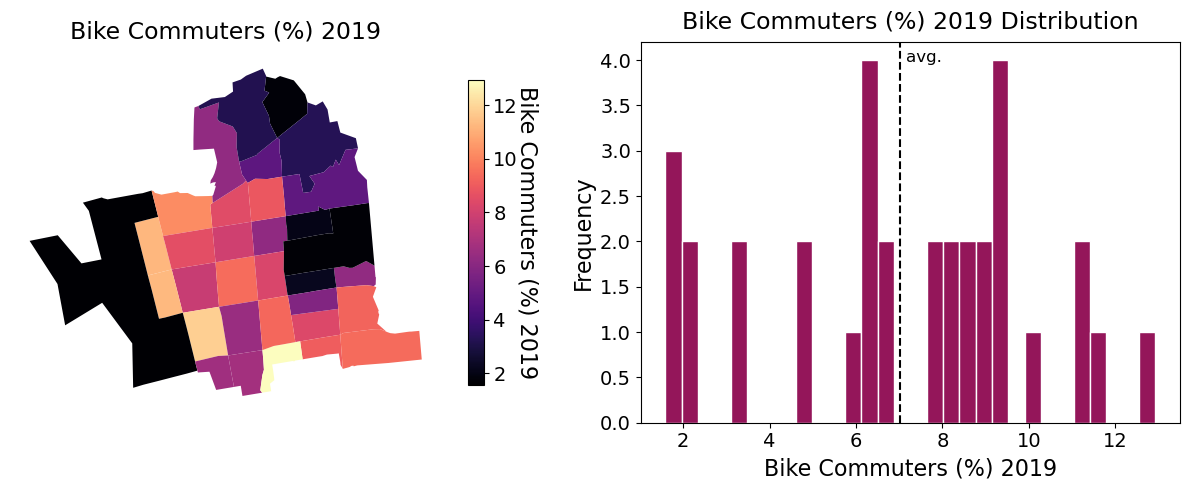

In [31]:
bky_tracts = bky_tracts.rename(
    columns={"bike_pct": "Bike Commuters (%) 2019"}
)
acquire.quick_viz(bky_tracts, "Bike Commuters (%) 2019") # quick viz for basic intuition

## 5-Year ACS Estimate for 2014 (Berkeley)

In [32]:
%%capture
gdf_old = acquire.get_censhp(
    variables=vars,
    geography='tract',
    state='CA',
    county='Alameda',
    year=2014,
    dataset='acs5',
)

In [33]:
%%capture
bky_gdf_old = acquire.get_censhp(
    variables=vars,
    geography='tract',
    state='CA',
    place='Berkeley',
    year=2014,
    dataset='acs5'
)

In [34]:
# gdf_old = gdf_old.to_crs(bky_gdf_old.crs)
# bky_mask_old = bky_gdf_old.dissolve()
# bky_tracts_old = gpd.clip(gdf_old, bky_mask_old)

In [35]:
bky_ids_old = set(bky_gdf_old["GEOID"])  
bky_tracts_old = gdf_old[gdf_old["GEOID"].isin(bky_ids)].copy()

bky_tracts_old["bike_pct"] = (
    bky_tracts_old["bike_commuters"] / bky_tracts_old["total_commuters"] * 100
)

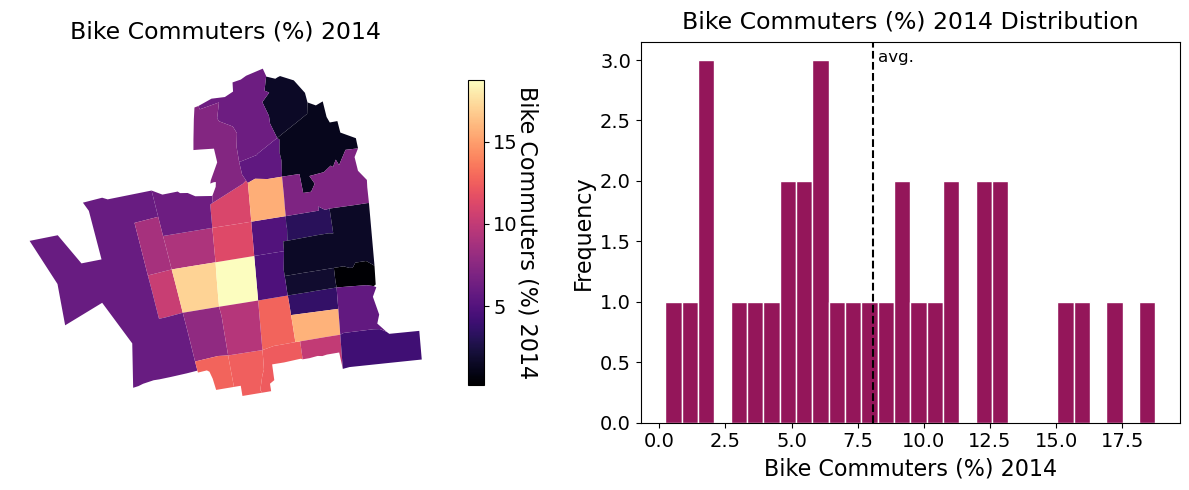

In [36]:
bky_tracts_old["bike_pct"] = bky_tracts_old["bike_commuters"]/bky_tracts_old["total_commuters"]*100

bky_tracts_old = bky_tracts_old.rename(
    columns={"bike_pct": "Bike Commuters (%) 2014"}
)
acquire.quick_viz(bky_tracts_old, "Bike Commuters (%) 2014") # quick viz for basic intuition

## % Change in Ridership

In [38]:
bky_tracts = bky_tracts.rename(
    columns={"Bike Commuters (%) 2019": "bike_pct"}
)

bky_tracts_old = bky_tracts_old.rename(
    columns={"Bike Commuters (%) 2014": "bike_pct_old"}
)

merged = bky_tracts.merge(
    bky_tracts_old[["GEOID", "bike_pct_old"]],
    on="GEOID"
)

In [57]:
merged["pct_change"] = (
    (merged["bike_pct"] - merged["bike_pct_old"]) /
    merged["bike_pct_old"]
)

merged = merged[['geometry', 'bike_pct', 'bike_pct_old', 'pct_change']]

merged.head(5)

print(merged.iloc[2,0])

POLYGON ((-122.254588 37.869321, -122.252328 37.869616, -122.25097099999999 37.869327999999996, -122.250214 37.869346, -122.247097 37.870591999999995, -122.245156 37.869737, -122.244928 37.867684, -122.244826 37.867582, -122.244877 37.866276, -122.245338 37.865986, -122.246962 37.866158999999996, -122.24842 37.866082999999996, -122.251653 37.865887, -122.253954 37.865736999999996, -122.254223 37.866931, -122.254588 37.869321))


Text(0.5, 1.0, 'Change in Bike Commuting (2014–2019)')

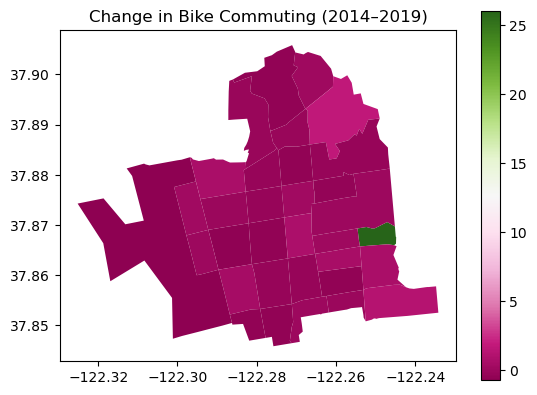

In [46]:
import matplotlib.pyplot as plt

merged.plot(column="pct_change", cmap="PiYG", legend=True)
plt.title("Change in Bike Commuting (2014–2019)")